<img src="assets/OFE-color-horizontal.png" width="300">

# Running a relative binding free energy campaign with OpenFE

*OpenFE: CCPBiosim 2026 Training Week — 2nd October 2026.*

In this notebook we will use [OpenFE](https://openfree.energy/) to plan and set up a relative
binding free energy (RBFE) campaign for a small series of fragments binding to MCL-1, first using
the OpenFE command line interface (CLI), and then using the Python API to build a more customised
campaign.

By the end of this tutorial you will be able to:

- Explain what a hybrid topology RBFE calculation is, and why we run one solvent and one complex
  simulation per ligand pair.
- Plan an entire RBFE campaign in three CLI commands.
- Use the OpenFE Python API to build a custom campaign: choosing your own atom mapper, network
  topology, protocol settings, and partial charge method.
- Know where to look to run and analyse the resulting simulations.

For more information, we refer you to:

- The [OpenFE documentation](https://docs.openfree.energy/en/stable/)
- Mey et al., ["Best Practices for Alchemical Free Energy Calculations"](https://livecomsjournal.org/index.php/livecoms/article/view/v2i1e18378), Living J. Comp. Mol. Sci. (2020)
- The OpenFE large-scale RBFE benchmarking study (Baumann et al.) — see the
  [OpenFE documentation](https://docs.openfree.energy/en/stable/) for the reference list

## Overview

| Section | What we'll cover |
|:---|:---|
| Background: the system | The MCL-1 protein and ligand series we'll be working with |
| Background: hybrid topology RBFE | The thermodynamic cycle behind an RBFE calculation |
| The OpenFE CLI | Planning an entire campaign in 3 commands: charge, plan, gather |
| The OpenFE Python API | Building a fully custom campaign: mapper, network, protocol, settings |
| Review & Conclusions | Recap, and where to go next |

## Background: the system

Throughout this tutorial we'll be working with a fragment series binding to **MCL-1**
(induced myeloid leukemia cell differentiation protein), an anti-apoptotic protein and cancer
drug target. The dataset comes from the Schrödinger fragments series
(Steinbrecher et al., *J. Chem. Inf. Model.* 2015) — a set of small, closely related ligands that
is a common benchmark for RBFE methods because the transformations involved are small and fast to
converge.

The inputs live under `./data`:

- `ligands.sdf` — 14 small fragment ligands, all pre-aligned to a common binding pose (this
  matters for hybrid topology, see below!).
- `protein.pdb` — the MCL-1 receptor, a single protein chain with no crystallographic waters or
  ions.

Loaded 14 ligands


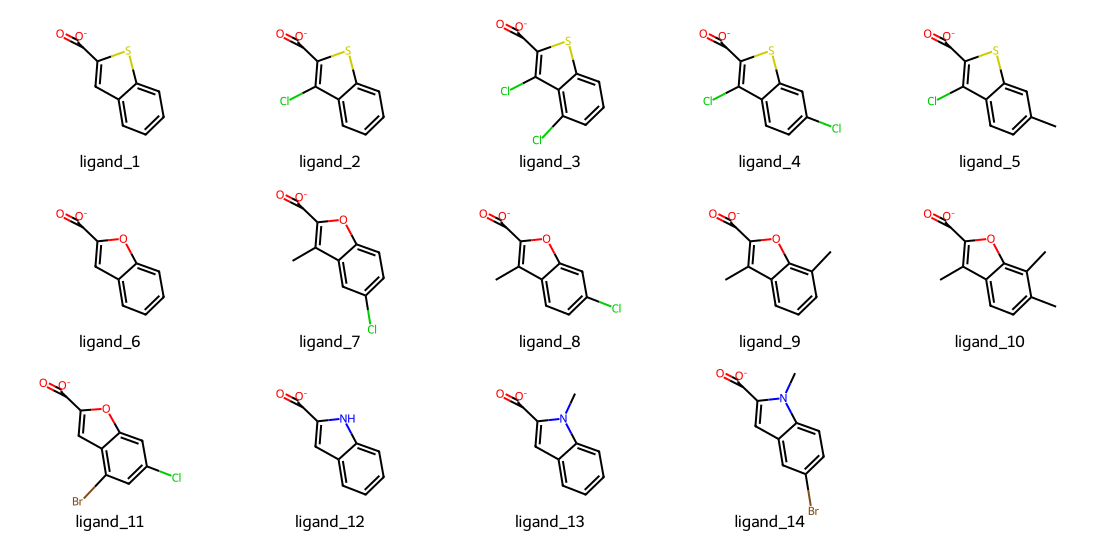

In [1]:
from rdkit import Chem
from rdkit.Chem.Draw import MolsToGridImage

supplier = Chem.SDMolSupplier("data/ligands.sdf", removeHs=False)
ligand_rdmols = list(supplier)
print(f"Loaded {len(ligand_rdmols)} ligands")

# Depict the ligands in 2D (stripping explicit hydrogens just for the drawing)
MolsToGridImage(
    [Chem.RemoveHs(mol) for mol in ligand_rdmols],
    legends=[mol.GetProp("_Name") for mol in ligand_rdmols],
    molsPerRow=5,
    subImgSize=(220, 180),
)

These are fragment-sized modifications of one another — small substituent swaps rather than
wholesale scaffold changes — which is exactly the kind of series hybrid topology RBFE handles well.

Let's also look at what one of these ligands looks like bound to the protein:

In [2]:
import py3Dmol

view = py3Dmol.view(width=600, height=400)

with open("data/protein.pdb") as f:
    view.addModel(f.read(), "pdb")
view.setStyle({"model": 0}, {"cartoon": {"color": "lightgrey"}})

example_ligand = ligand_rdmols[0]
view.addModel(Chem.MolToMolBlock(example_ligand), "mol")
view.setStyle({"model": 1}, {"stick": {"colorscheme": "cyanCarbon"}})

view.zoomTo({"model": 1})
view.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

<div style="background-color:#d9edf7; border-left: 6px solid #2196F3; padding: 12px 16px; border-radius: 4px; margin: 10px 0;">

💡 **Info**


This view is generated on the fly from the files in `./data` — we don't have a pre-rendered
"hero image" of the complex to ship with this tutorial, so we're building one ourselves with
[py3Dmol](https://pypi.org/project/py3Dmol/) instead.


</div>

## Background: hybrid topology binding free energies

OpenFE's default RBFE method is a **hybrid topology** protocol. Rather than simulating each
ligand's binding free energy in isolation (which converges very slowly), we compute the
*relative* binding free energy, ΔΔG, between pairs of similar ligands using a thermodynamic cycle:

```
        ΔG_complex(A→B)
   A:protein  ------------->  B:protein
       |                          |
       | ΔG_bind(A)               | ΔG_bind(B)
       |                          |
       v                          v
   A:solvent  ------------->  B:solvent
        ΔG_solvent(A→B)
```

Because this cycle is closed, we don't need to compute either of the (very hard to converge)
vertical legs directly:

```
ΔΔG_bind(A→B) = ΔG_bind(B) − ΔG_bind(A) = ΔG_complex(A→B) − ΔG_solvent(A→B)
```

Each horizontal leg is an **alchemical transformation**: rather than physically unbinding a
ligand, we gradually mutate ligand A into ligand B in both environments, keeping track of the free
energy change along the way. This means every ligand pair in an RBFE campaign requires **two**
simulations: one with the ligand transforming in solvent, and one with it transforming in the
protein-bound complex.

In a *hybrid topology* approach specifically, both end-state ligands are described within a single
"combined" molecule: atoms common to both ligands (the "core") are simply interpolated, while
atoms unique to either end state are grown in or removed as dummy atoms over the course of the
simulation. Because only the non-common atoms are perturbed, these transformations are usually
much smaller — and therefore much cheaper to converge — than a full absolute binding free energy
calculation.

This comes with some trade-offs:

- **You need a common core.** Ligands must share a reasonable amount of chemical scaffold for a
  sensible hybrid topology mapping to exist. If you want to compare ligands with completely
  different scaffolds ("scaffold hopping"), you'll need a separated-topology method like
  [SepTop](https://docs.openfree.energy/en/stable/guide/protocols/septop/septop_overview.html)
  instead.
- **Ligands must be pre-aligned.** The atom mapper needs the 3D coordinates of both ligands to
  already agree on how the shared core overlaps — this is why `ligands.sdf` ships with all 14
  ligands in a common pose.
- **It isn't a formally exact method.** Handling dummy atoms introduces some approximations that
  can occasionally bias the free energy estimate for particularly large or awkward
  transformations (see Fleck et al. on dummy-atom artefacts in alchemical calculations). In
  practice, though, hybrid topology RBFE is still very accurate — substantially more so than
  end-point methods like MM-GBSA — as shown in OpenFE's own large-scale benchmarking study
  (Baumann et al.; see the [OpenFE documentation](https://docs.openfree.energy/en/stable/) for the
  full reference).

Zooming out, an RBFE campaign with OpenFE follows the same general workflow, whichever ligand
pair you're looking at:

```
 ligands (.sdf)  ─┐
                  ├─▶  map + score pairs  ─▶  build network  ─▶  run each edge
 protein  (.pdb) ─┘        (atom mapper)      (which pairs?)     (solvent + complex)
                                                                          │
                                                                          ▼
                                                                gather ΔG / ΔΔG estimates
```

We don't have a polished workflow diagram asset to include here (there isn't one for the RBFE
protocol under `ExampleNotebooks`, unlike the ABFE/AHFE/SepTop tutorials which each ship one) — the
schematic above stands in for it. Every box in that diagram is something we'll build by hand in
this notebook, first with the CLI and then with the Python API.

## The OpenFE CLI: end-to-end RBFEs using three simple commands

### Using terminal commands in a notebook

Jupyter lets you run shell commands directly from a code cell by prefixing the line with `!`. This
is how we'll drive the OpenFE CLI for the rest of this section — everything after `!` is executed
in a terminal, not in Python.

We can use this to poke around the files we're working with. For example, let's list what's in
`./data`:

In [3]:
!ls -la data

total 232
drwxr-xr-x 2 bioc1523 bioc1523   4096 Sep 14 00:30 .
drwxr-xr-x 4 bioc1523 bioc1523   4096 Sep 14 01:13 ..
-rw-r--r-- 1 bioc1523 bioc1523  26855 Sep 14 00:30 ligands.sdf
-rw-r--r-- 1 bioc1523 bioc1523 199883 Sep 14 00:30 protein.pdb


We can also peek inside a file without opening it in an editor, using `head` (show the first N
lines) or `cat` (show the whole file). Let's look at the start of the protein PDB file:

In [4]:
!head -n 5 data/protein.pdb

HEADER    
TITLE     MDANALYSIS FRAME 0: Created by PDBWriter
CRYST1   60.360   60.360   60.360  90.00  90.00  90.00 P 1           1
ATOM      1  N   GLY A   1     -18.585  -3.460   7.728  1.00  0.00      A    N  
ATOM      2  H   GLY A   1     -19.381  -3.217   7.146  1.00  0.00      A    H  


### Introduction to the OpenFE CLI

OpenFE provides a command line interface (CLI) as a simple entry point into running binding free
energy calculations:

- It automatically uses our best-practice defaults.
- It has limited customisability — if you want to change the simulation length, the force field,
  or almost anything else, you'll need the Python API (covered later in this notebook).
- Its network planning is limited to a single calculation type: hybrid topology RBFE (see the
  accompanying slides for how this compares to the other Protocols OpenFE supports).
- Despite this simplicity, it's what most of our industry partners use in practice, and it's what
  we used to run the simulations in OpenFE's own large-scale benchmarking study.

Let's start by looking at the top-level help:

In [5]:
!openfe -h

Usage: openfe [OPTIONS] COMMAND [ARGS]...

  A command line interface to provide access to basic functionality of the
  openfe Python library.

Options:
  --version   Show the version and exit.
  --log PATH  logging configuration file
  -h, --help  Show this message and exit.

Network Planning Commands:
  view-ligand-network  Visualize a ligand network from a .graphml file.
  plan-rbfe-network    Plan a relative binding free energy network, saved as
                       JSON files for the quickrun command.
  plan-rhfe-network    Plan a relative hydration free energy network, saved as
                       JSON files for the quickrun command.

Quickrun Executor Commands:
  gather-abfe    Gather result JSONs for network of ABFE results into a TSV
                 file.
  gather         Gather result JSONs for network of RBFE results into a TSV
                 file.
  gather-septop  Gather result JSONs for a network of SepTop results into a
                 TSV file.
  quickrun       

The CLI is organised into subcommands. Each one has its own `-h`/`--help`, for example:

In [6]:
!openfe charge-molecules -h

Usage: openfe charge-molecules [OPTIONS]

  Generate partial charges for the set of input molecules and write them to
  file.

Options:
  -M, --molecules PATH   A directory or file containing all molecules to be
                         loaded, either as a single SDF or multiple MOL2/SDFs.
                         Any number of sdf paths.  [required]
  -s, --settings FILE    Path to a YAML file specifying the method to use to
                         charge the molecules (any atom mapper or network
                         generation options will be ignored).
                         
                         Supported partial charge method choices are:     -
                         ``am1bcc``     - ``am1bccelf10`` (only possible if
                         ``off_toolkit_backend`` is ``openeye``)     -
                         ``nagl`` (must have openff-nagl installed)     -
                         ``espaloma`` (must have espaloma_charge installed)
                         - ``forcef

### An RBFE workflow using the CLI

An RBFE campaign with the CLI comes down to four commands:

1. `openfe charge-molecules` — assign partial charges to every ligand up front.
2. `openfe plan-rbfe-network` — map, score, and network the ligands, and write out one
   simulation-ready input file per leg.
3. `openfe quickrun` — execute each of those simulations.
4. `openfe gather` — collect the finished results into a table of ΔG / ΔΔG values.

```
 data/ligands.sdf ──▶ 1. charge-molecules ──▶ ligands_am1bcc.sdf
                                                     │
 data/protein.pdb ───────────────────────────┐      │
                                              ▼      ▼
                                   2. plan-rbfe-network
                                              │
                                              ▼
                          network_setup/transformations/*.json
                                              │
                                              ▼
                                    3. quickrun  (skipped here — too slow for a tutorial!)
                                              │
                                              ▼
                                       4. gather ──▶ ΔG / ΔΔG table
```

### Adding partial charges to molecules

Conventional partial charge assignment methods (like AM1-BCC) aren't perfectly reproducible —
tiny numerical differences between runs, of order 0.03 e, are common (see Osato et al. on
reproducibility of semiempirical partial charges). Free energy calculations are sensitive enough
that this can introduce a small discontinuity into our thermodynamic cycle if, say, the solvent
and complex legs of the same ligand ended up with very slightly different charges.

To avoid this, we assign partial charges to every ligand **once**, up front, and reuse those same
charges for every transformation that ligand appears in.

OpenFE is built on the [OpenFF toolkit](https://docs.openforcefield.org/projects/toolkit/), and
supports several partial charge methods:

- `am1bcc` — the default, computed with AmberTools (no extra dependencies).
- `am1bccelf10` — a conformer-averaged AM1-BCC (requires the OpenEye toolkit, which needs a
  license, so we won't demo it here).
- `nagl` — OpenFF-NAGL, a fast graph neural network charge model.
- `espaloma` — another neural-network charge model (requires `espaloma-charge`, not installed in
  this environment).

The `openfe charge-molecules` command adds partial charges to a set of molecules. By default it
uses AM1BCC via AmberTools, but this can be controlled with a settings YAML file. We've written
one out at `partial_charge_settings.yaml`, spelling out the defaults explicitly:

In [7]:
!cat partial_charge_settings.yaml

partial_charge:
  method: am1bcc
  settings:
    off_toolkit_backend: ambertools
    number_of_conformers: null
    nagl_model: null


Now let's add partial charges to the ligands in `data/ligands.sdf` using this settings file:

In [8]:
!mkdir -p cli_output
!openfe charge-molecules -M data/ligands.sdf -s partial_charge_settings.yaml -o cli_output/ligands_am1bcc.sdf -n 4

SMALL MOLECULE PARTIAL CHARGE GENERATOR
_________________________________________



Parsing in Files: 
	Got input: 


		Small Molecules: SmallMoleculeComponent(name=ligand_1) SmallMoleculeComponent(name=ligand_2) SmallMoleculeComponent(name=ligand_3) SmallMoleculeComponent(name=ligand_4) SmallMoleculeComponent(name=ligand_5) SmallMoleculeComponent(name=ligand_6) SmallMoleculeComponent(name=ligand_7) SmallMoleculeComponent(name=ligand_8) SmallMoleculeComponent(name=ligand_9) SmallMoleculeComponent(name=ligand_10) SmallMoleculeComponent(name=ligand_11) SmallMoleculeComponent(name=ligand_12) SmallMoleculeComponent(name=ligand_13) SmallMoleculeComponent(name=ligand_14)
Using Options:
	Partial Charge Generation: am1bcc



Generating charges:   0%|                                | 0/14 [00:00<?, ?it/s]

Generating charges:   7%|█▋                      | 1/14 [00:05<01:08,  5.27s/it]

...

Generating charges:  79%|██████████████████     | 11/14 [00:28<00:05,  1.83s/it]

Generating charges:  86%|███████████████████▋   | 12/14 [00:33<00:05,  2.86s/it]

Generating charges:  93%|█████████████████████▎ | 13/14 [00:35<00:02,  2.62s/it]

Generating charges: 100%|███████████████████████| 14/14 [00:43<00:00,  3.09s/it]


	Done

Output:
	Saving to: cli_output/ligands_am1bcc.sdf


This has written a new SDF file, `cli_output/ligands_am1bcc.sdf`, containing all 14 ligands along
with their atomic partial charges stored as an SDF property. We can see this by looking at the
first molecule's record:

In [9]:
!head -n 48 cli_output/ligands_am1bcc.sdf

ligand_1
     RDKit          3D

 17 18  0  0  0  0  0  0  0  0999 V2000
    4.6809    9.3408    2.6108 H   0  0  0  0  0  0  0  0  0  0  0  0
    9.0600    8.2460    4.8940 C   0  0  0  0  0  0  0  0  0  0  0  0
    3.6880   12.5790    3.5530 O   0  0  0  0  0  0  0  0  0  0  0  0
    7.2160   11.7060    4.0430 S   0  0  0  0  0  0  0  0  0  0  0  0
    8.1260    7.3410    4.4090 C   0  0  0  0  0  0  0  0  0  0  0  0
    4.6760   12.4490    1.6410 O   0  0  0  0  0  0  0  0  0  0  0  0
    8.8210    9.5760    4.7570 C   0  0  0  0  0  0  0  0  0  0  0  0
    6.9420    7.8020    3.7580 C   0  0  0  0  0  0  0  0  0  0  0  0
    4.6240   12.1020    2.8350 C   0  0  0  0  0  0  0  0  0  0  0  0
    5.5220    9.8290    3.1030 C   0  0  0  0  0  0  0  0  0  0  0  0
    5.6260   11.1390    3.3520 C   0  0  0  0  0  0  0  0  0  0  0  0
    7.6510    9.9970    4.0730 C   0  0  0  0  0  0  0  0  0  0  0  0
    6.7200    9.1620    3.5990 C   0  0  0  0  0  0  0  0  0  0  0  0
    9.5169   10.3

The block under `>  <atom.dprop.PartialCharge>` lists the per-atom partial charges for
`ligand_1`, in the same atom order as the molecule block above it.

<div style="background-color:#d9edf7; border-left: 6px solid #2196F3; padding: 12px 16px; border-radius: 4px; margin: 10px 0;">

💡 **Info**


See the [partial charge assignment cookbook](https://docs.openfree.energy/en/stable/cookbook/user_charges.html)
for more on the available partial charge methods and how to configure them.


</div>

### Planning a network of RBFE simulations

Now that our ligands are charged, we need to actually build the set of simulations that will let
us calculate relative free energies between them. This step involves:

- **Mapping** how each ligand pair could transform into one another (which atoms appear, which
  disappear, and which are common between the two).
- **Scoring** every candidate mapping, as a proxy for how hard that transformation will be to
  converge.
- Using those scores to choose a **network**: which ligand pairs we'll actually simulate.
- Creating the simulation **protocol**.
- Writing out the simulation **input files**.

All of this happens in a single command: `openfe plan-rbfe-network`.

By default, this command builds a minimal spanning network (the smallest set of edges that
connects every ligand, weighted to favour easier transformations), mapping atoms with the
[Kartograf](https://github.com/OpenFreeEnergy/kartograf) atom mapper and scoring them with the
default LOMAP scorer, then sets up the OpenMM-based hybrid topology RFE protocol with its default
settings.

<div style="background-color:#d9edf7; border-left: 6px solid #2196F3; padding: 12px 16px; border-radius: 4px; margin: 10px 0;">

💡 **Info**


Some of these choices (the mapper, the network algorithm, the partial charge method) can be
overridden with a settings YAML file passed via `-s`, in the same style as
`partial_charge_settings.yaml` above. We won't use one here — see
`openfe plan-rbfe-network -h` for the full set of options, or the
[RBFE CLI tutorial](https://docs.openfree.energy/en/stable/tutorials/rbfe_cli_tutorial.html) for a
worked example.


</div>

Let's plan our network. We pass in our pre-charged ligands and the protein, and ask for a single
protocol repeat per transformation (so we control how many repeats to run ourselves, later, with
`quickrun`):

In [10]:
!openfe plan-rbfe-network -M cli_output/ligands_am1bcc.sdf -p data/protein.pdb -o cli_output/network_setup --n-protocol-repeats 1 -n 4

RBFE-NETWORK PLANNER
______________________



Parsing in Files: 
	Got input: 
		Small Molecules: SmallMoleculeComponent(name=ligand_1) SmallMoleculeComponent(name=ligand_2) SmallMoleculeComponent(name=ligand_3) SmallMoleculeComponent(name=ligand_4) SmallMoleculeComponent(name=ligand_5) SmallMoleculeComponent(name=ligand_6) SmallMoleculeComponent(name=ligand_7) SmallMoleculeComponent(name=ligand_8) SmallMoleculeComponent(name=ligand_9) SmallMoleculeComponent(name=ligand_10) SmallMoleculeComponent(name=ligand_11) SmallMoleculeComponent(name=ligand_12) SmallMoleculeComponent(name=ligand_13) SmallMoleculeComponent(name=ligand_14)


		ProteinComponent: ProteinComponent(name=)
		Cofactors: []
		Solvent: SolventComponent(name=O, Na+, Cl-)

Using Options:
	Mapper: <KartografAtomMapper-92be13375caab9a5f2ecbf75d925982f>
	Mapping Scorer: <function default_lomap_score at 0x7a7547475590>
	Network Generation: <function generate_minimal_spanning_network at 0x7a7544dc16f0>
	Partial Charge Generation: am1bcc

	n_protocol_repeats=1 (1 simulation repeat(s) per transformation)

Planning RBFE-Campaign:
assigning ligand partial charges -- this may be slow


Generating charges:   0%|                                | 0/14 [00:00<?, ?it/s]

Generating charges: 100%|███████████████████████| 14/14 [00:04<00:00,  3.47it/s]


...

				- rbfe_ligand_1_complex_ligand_2_complex.json


				- rbfe_ligand_1_solvent_ligand_2_solvent.json


				- rbfe_ligand_6_complex_ligand_7_complex.json
				- rbfe_ligand_6_solvent_ligand_11_solvent.json


				- rbfe_ligand_4_complex_ligand_5_complex.json


				- rbfe_ligand_6_complex_ligand_12_complex.json
				- rbfe_ligand_9_solvent_ligand_10_solvent.json
				- rbfe_ligand_13_solvent_ligand_14_solvent.json
	Duration: 0:00:09.935569



Notice in the log above that charge generation for our ligands was almost instant this time —
`plan-rbfe-network` detected that our ligands already carry partial charges and reused them,
rather than recomputing AM1BCC from scratch. This is exactly the reproducibility guarantee we were
after.

Let's look at what was created:

In [11]:
!ls cli_output/network_setup

ligand_network.graphml	network_setup.json  transformations


- `network_setup.json` describes the whole planned `AlchemicalNetwork`.
- `ligand_network.graphml` describes just the ligands and how they're connected.
- `transformations/` is the one you care about most day-to-day — one JSON file per simulation leg,
  each one a complete, self-contained input for `openfe quickrun`:

In [12]:
!ls cli_output/network_setup/transformations

rbfe_ligand_12_complex_ligand_13_complex.json
rbfe_ligand_12_solvent_ligand_13_solvent.json
rbfe_ligand_13_complex_ligand_14_complex.json
rbfe_ligand_13_solvent_ligand_14_solvent.json
rbfe_ligand_1_complex_ligand_2_complex.json
rbfe_ligand_1_complex_ligand_6_complex.json
rbfe_ligand_1_solvent_ligand_2_solvent.json
rbfe_ligand_1_solvent_ligand_6_solvent.json
rbfe_ligand_2_complex_ligand_3_complex.json
rbfe_ligand_2_complex_ligand_4_complex.json
rbfe_ligand_2_solvent_ligand_3_solvent.json
rbfe_ligand_2_solvent_ligand_4_solvent.json
rbfe_ligand_4_complex_ligand_5_complex.json
rbfe_ligand_4_complex_ligand_8_complex.json
rbfe_ligand_4_solvent_ligand_5_solvent.json
rbfe_ligand_4_solvent_ligand_8_solvent.json
rbfe_ligand_6_complex_ligand_11_complex.json
rbfe_ligand_6_complex_ligand_12_complex.json
rbfe_ligand_6_complex_ligand_7_complex.json
rbfe_ligand_6_solvent_ligand_11_solvent.json
rbfe_ligand_6_solvent_ligand_12_solvent.json
rbfe_ligand_6_solvent_ligand_7_solvent.json
rbfe_ligand_8_comple

With 14 ligands, a minimal spanning network has 13 edges, and each edge needs both a solvent and a
complex leg — hence 26 JSON files.

You can interactively explore a planned network from the terminal with
`openfe view-ligand-network cli_output/network_setup/ligand_network.graphml`, which opens a
draggable viewer where clicking an edge shows you its atom mapping. That command opens its own
window rather than rendering inline, so we won't run it here — instead, let's use
[konnektor](https://github.com/OpenFreeEnergy/konnektor)'s visualisation directly on the network we
just planned:

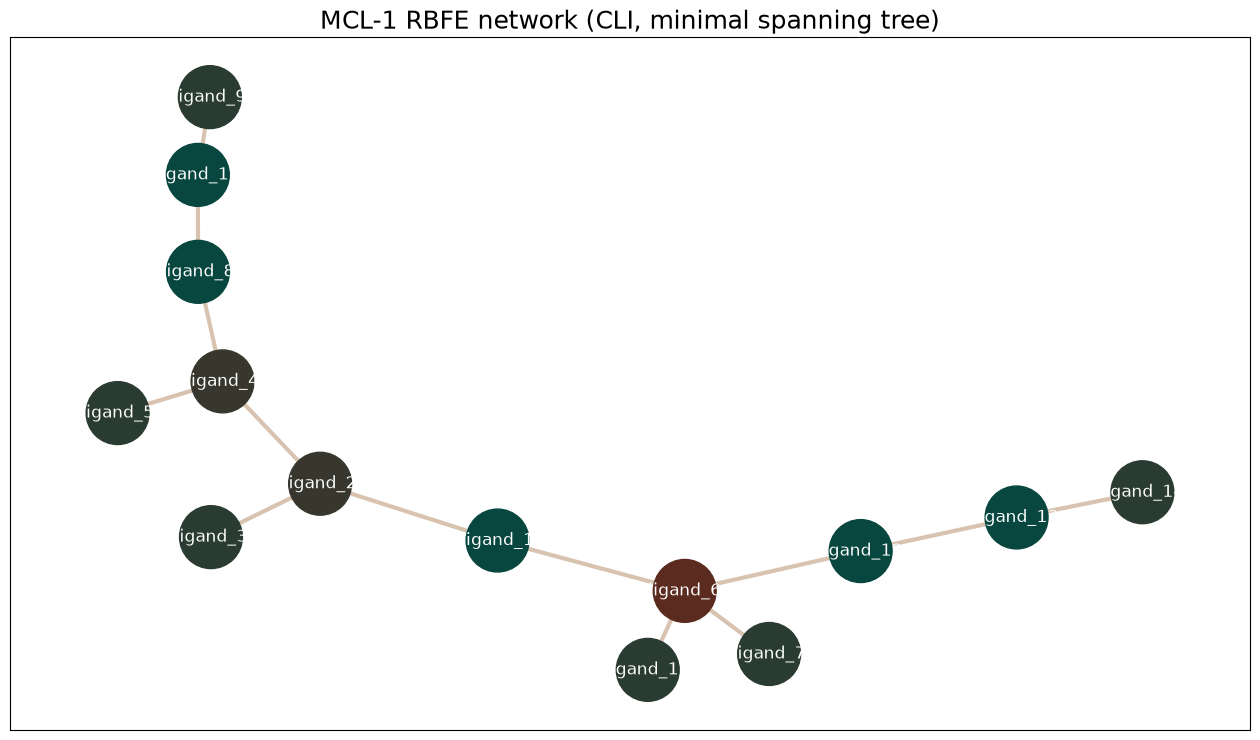

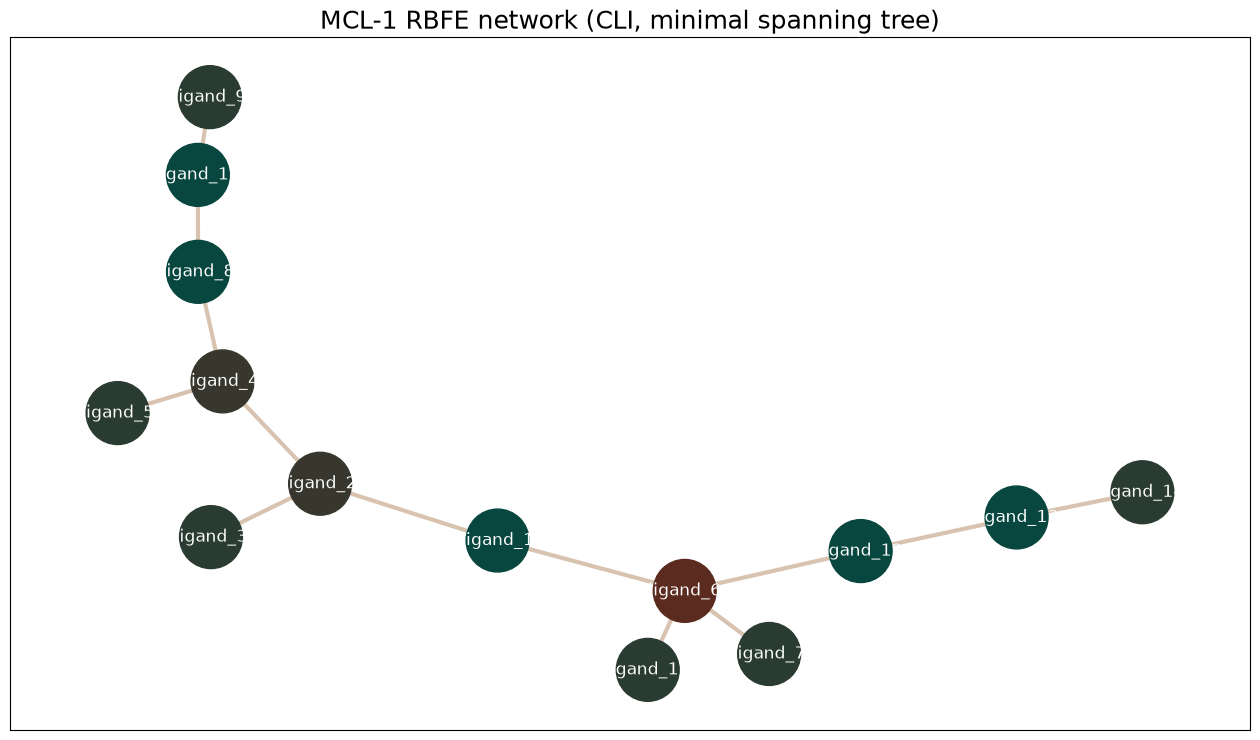

In [13]:
import openfe
import konnektor

with open("cli_output/network_setup/ligand_network.graphml") as f:
    cli_ligand_network = openfe.LigandNetwork.from_graphml(f.read())

konnektor.draw_ligand_network(cli_ligand_network, title="MCL-1 RBFE network (CLI, minimal spanning tree)")

### Executing simulations

<div style="background-color:#fdecea; border-left: 6px solid #f44336; padding: 12px 16px; border-radius: 4px; margin: 10px 0;">

⚠️ **Warning**


We are **not** going to run any simulations in this tutorial — even at reduced settings, a single
RBFE leg takes far longer than we have time for here, and running 26 of them would need
substantial GPU resources.

If you did want to run these simulations, each leg is executed independently with `openfe
quickrun`, for example:

```bash
openfe quickrun cli_output/network_setup/transformations/rbfe_ligand_1_solvent_ligand_2_solvent.json \
    -o results/rbfe_ligand_1_solvent_ligand_2_solvent.json \
    -d results/rbfe_ligand_1_solvent_ligand_2_solvent/
```

and best practice is to run each leg 3 times independently (3 repeats) to get an uncertainty
estimate.


</div>

<div style="background-color:#d9edf7; border-left: 6px solid #2196F3; padding: 12px 16px; border-radius: 4px; margin: 10px 0;">

💡 **Info**


See the [RBFE CLI tutorial](https://docs.openfree.energy/en/stable/tutorials/rbfe_cli_tutorial.html#2-run-the-simulations)
for more detail on running simulations, including a template for submitting each leg as its own
HPC job.


</div>

### Gathering results

<div style="background-color:#d9edf7; border-left: 6px solid #2196F3; padding: 12px 16px; border-radius: 4px; margin: 10px 0;">

💡 **Info**


This section is intentionally left without example output: we haven't run any of the simulations
above, so there are no result JSONs to gather yet. Once you *have* run a campaign, results are
gathered with `openfe gather`, which reads every result JSON under a directory and reports:

- `openfe gather --report raw results/` — the raw ΔG for every individual leg and repeat, with no
  combining across redundant simulations.
- `openfe gather --report ddg results/` — the relative free energy ΔΔG(i→j) between each simulated
  ligand pair, combining repeats.
- `openfe gather --report dg results/` (the default) — a single absolute ΔG per ligand, obtained
  via a maximum-likelihood estimate across the whole network, together with its uncertainty. These
  values are centred on an arbitrary zero-point, so they're only meaningful relative to each other
  (or once shifted to match an experimental reference value).


</div>

## The OpenFE Python API: running custom RBFE simulations

The CLI is convenient, but sometimes you need something it can't give you — a longer simulation,
a different force field, a non-default network topology. For that, we turn to the Python API.

We'll now set up the *same kind* of campaign as above, but with a few deliberate changes to show
off what the API lets you customise:

- We'll build a **redundant minimal spanning tree** network instead of a plain MST, giving us
  some redundancy to fall back on if an edge fails.
- We'll run for **10 ns** of production instead of the CLI's default 5 ns.
- We'll use **AshGC** partial charges together with the newest **OpenFF 2.3.0** force field
  (AshGC is the charge model OpenFF 2.3.0 was fitted against).

### Loading molecules

To build a campaign by hand, we need Python objects describing every part of the system. OpenFE
represents these as **Components** — the pieces that get composed together into a full chemical
system (we'll meet the `ChemicalSystem` class itself shortly).

We already loaded our ligands with RDKit earlier in this notebook (`ligand_rdmols`); let's wrap
them as `SmallMoleculeComponent`s:

In [14]:
ligands = [openfe.SmallMoleculeComponent.from_rdkit(mol) for mol in ligand_rdmols]
ligands[:3]

[SmallMoleculeComponent(name=ligand_1),
 SmallMoleculeComponent(name=ligand_2),
 SmallMoleculeComponent(name=ligand_3)]

The protein is loaded as a `ProteinComponent`, and the solvent — water plus counter-ions — is
described with a `SolventComponent`:

In [15]:
protein = openfe.ProteinComponent.from_pdb_file("data/protein.pdb")

# defaults are TIP3P water, neutralised with NaCl at 0.15 M ionic strength
solvent = openfe.SolventComponent()
protein, solvent

(ProteinComponent(name=), SolventComponent(name=O, Na+, Cl-))

<div style="background-color:#d9edf7; border-left: 6px solid #2196F3; padding: 12px 16px; border-radius: 4px; margin: 10px 0;">

💡 **Info**


If you already have a pre-solvated, pre-equilibrated system (for example, one that includes a
membrane), you can use `SolvatedPDBComponent` or `ProteinMembraneComponent` instead of a separate
`ProteinComponent` + `SolventComponent` pair. See the
[OpenFE documentation](https://docs.openfree.energy/en/stable/) for more on preparing
membrane-containing systems.


</div>

### Generating partial charges

Just like `openfe charge-molecules` on the CLI, the Python API has a function for bulk-assigning
partial charges: `bulk_assign_partial_charges`. Here we'll use it to assign AshGC charges — a
graph neural network charge model, distributed as the NAGL model `openff-gnn-am1bcc-1.0.0.pt` —
since that's the charge model OpenFF 2.3.0 (the force field we'll use below) was fitted for.

In [16]:
from openfe.protocols.openmm_utils.charge_generation import bulk_assign_partial_charges

ligands = bulk_assign_partial_charges(
    molecules=ligands,
    overwrite=False,
    method="nagl",
    toolkit_backend="ambertools",
    generate_n_conformers=None,
    nagl_model="openff-gnn-am1bcc-1.0.0.pt",
    processors=4,
)

Generating charges:   0%|                                | 0/14 [00:00<?, ?it/s]

Generating charges:   7%|█▋                      | 1/14 [00:05<01:06,  5.14s/it]

Generating charges:  36%|████████▌               | 5/14 [00:06<00:09,  1.01s/it]

Generating charges:  64%|███████████████▍        | 9/14 [00:07<00:03,  1.62it/s]

Generating charges:  93%|█████████████████████▎ | 13/14 [00:08<00:00,  2.39it/s]

Generating charges: 100%|███████████████████████| 14/14 [00:08<00:00,  1.72it/s]

We can confirm the charges are attached by converting a ligand to an OpenFF `Molecule` and
inspecting its `partial_charges`:

In [17]:
offmol = ligands[0].to_openff()
offmol.partial_charges

Magnitude,[0.15655915581566446 -0.17297535992282279 -0.8061116919578875 0.01683119640630834 -0.1747063682140673 -0.8061116919578875 -0.09443862593787558 -0.11695580042022116 0.9368329062400496 -0.1614670441212023 -0.09910420930999167 -0.10721677399295218 -0.06288055933135397 0.11742592745405786 0.12900521003586404 0.12569207095486276 0.1196216582594549]
Units,elementary_charge


### Defining a network of ligand transformations

In principle, we could try to compute the free energy between every possible pair of our 14
ligands. In practice, we don't want to:

1. It scales as O(n²) in the number of ligands — prohibitively expensive once you have more than a
   handful.
2. Not every transformation would even succeed — some ligand pairs are simply too different for a
   good hybrid topology mapping to exist.

Instead, all we actually need is a network that keeps every ligand **connected** to every other
ligand, even if only indirectly. Building that network is a three-step process: choose an atom
mapper, choose a scorer, then choose a network-planning algorithm.

#### Mapping two ligands

In a hybrid topology RBFE, an atom mapping tells us which atoms are unique to each end-state
ligand (and so will appear or disappear over the simulation) and which are common to both (and so
will simply be interpolated between the two states).

In the CLI example above, this was done automatically with the Kartograf atom mapper — OpenFE's
3D-first mapper, which uses the ligands' 3D coordinates to build a mapping. Let's use it directly
via the Python API on a single pair of ligands:

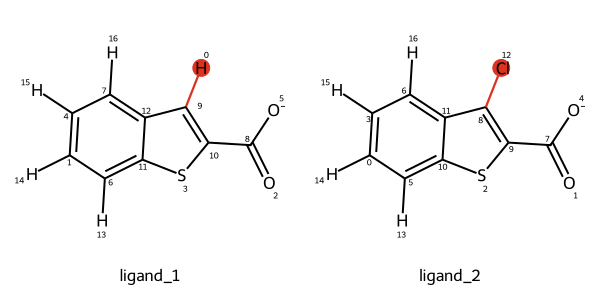

In [18]:
mapper = openfe.KartografAtomMapper()

# suggest_mappings returns a generator; Kartograf normally suggests a single mapping per pair
mapping = next(mapper.suggest_mappings(ligands[0], ligands[1]))
mapping

Displaying the mapping shows a 2D depiction of both ligands side by side. Atoms unique to one
ligand or the other (i.e. atoms that will appear/disappear) are highlighted in red; atoms that are
mapped but change element are shown in blue.

We can also look at the same mapping in 3D:

In [19]:
mapping.view_3d()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

Here, the left- and right-hand molecules are the two end states, and the middle panel overlays
them. Atoms drawn with matching sphere colours across both end states are mapped onto each other
(and so will be interpolated); atoms with no coloured sphere are unmapped, and will be grown in or
removed as dummy atoms.

<div style="background-color:#d9edf7; border-left: 6px solid #2196F3; padding: 12px 16px; border-radius: 4px; margin: 10px 0;">

💡 **Info**


See the [Planning a Ligand Network cookbook](https://docs.openfree.energy/en/stable/cookbook/generate_ligand_network.html)
and the [ligand network user guide](https://docs.openfree.energy/en/stable/guide/setup/creating_ligand_networks.html)
for more on atom mapping.


</div>

<div style="background-color:#e8f5e9; border-left: 6px solid #4caf50; padding: 12px 16px; border-radius: 4px; margin: 10px 0;">

✏️ **Exercise**


OpenFE also ships a second atom mapper, `openfe.LomapAtomMapper`, which works by maximum common
substructure (MCS) search rather than 3D geometry.

Try mapping the same pair of ligands (`ligands[0]` and `ligands[1]`) with `LomapAtomMapper()`
instead of `KartografAtomMapper()`, and compare the resulting mapping to the Kartograf one above.
Do they map the same atoms?


</div>

#### Scoring two ligands

To decide which ligand pairs are worth simulating, we need some way to estimate up front how
*hard* a given transformation will be — this is what an atom mapping **scorer** is for. A scorer
takes a `LigandAtomMapping` and returns a score from 0 (worst) to 1 (best).

Here we'll use the LOMAP scorer, which applies a set of empirical rules that penalise
transformations known to be difficult — for example, ones that grow or remove a lot of atoms at
once, or that break open a ring:

In [20]:
score = openfe.lomap_scorers.default_lomap_score(mapping)
score

0.9048374180359595

<div style="background-color:#e8f5e9; border-left: 6px solid #4caf50; padding: 12px 16px; border-radius: 4px; margin: 10px 0;">

✏️ **Exercise**


`openfe.lomap_scorers` has several other scoring functions beyond `default_lomap_score` — for
example `mcsr_score` (maximum common substructure size), `atomic_number_score`, and
`hybridization_score`.

*(Note: Kartograf doesn't currently ship a dedicated shape-overlap scorer in this OpenFE version,
so we can't demo that one here — the `lomap_scorers` functions are a good substitute to explore.)*

Try scoring the same `mapping` with one or two of these alternative scoring functions. Do they
agree with `default_lomap_score` about how easy this transformation is?


</div>

#### Creating ligand transformation networks

In the CLI example, `plan-rbfe-network` automatically built a minimal spanning tree (MST) — the
network with the fewest possible edges that still connects every ligand. Here, we'll instead build
a **redundant** MST, which keeps some extra edges around: if any one edge's simulation fails or
looks suspicious, we still have another path connecting those ligands.

Building a `LigandNetwork` just requires the mapper and scorer we defined above, plus the ligands
we want in the network:

In [21]:
mapper = openfe.KartografAtomMapper()
scorer = openfe.lomap_scorers.default_lomap_score

ligand_network = openfe.ligand_network_planning.generate_minimal_redundant_network(
    ligands=ligands,
    mappers=[mapper],
    scorer=scorer,
    mst_num=2,  # keep 2 independent spanning trees' worth of edges
)

print(f"{len(ligand_network.nodes)} ligands, {len(ligand_network.edges)} edges")

14 ligands, 26 edges


Let's visualise the resulting network with konnektor, first as a static plot:

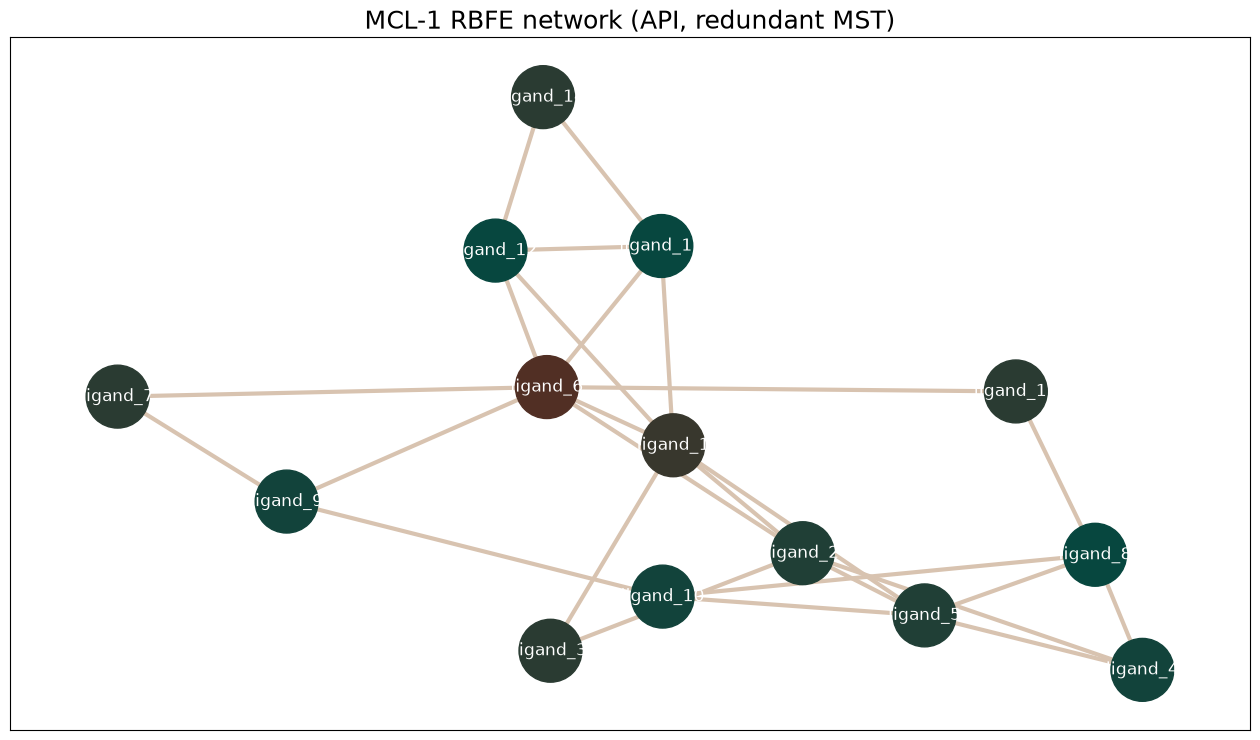

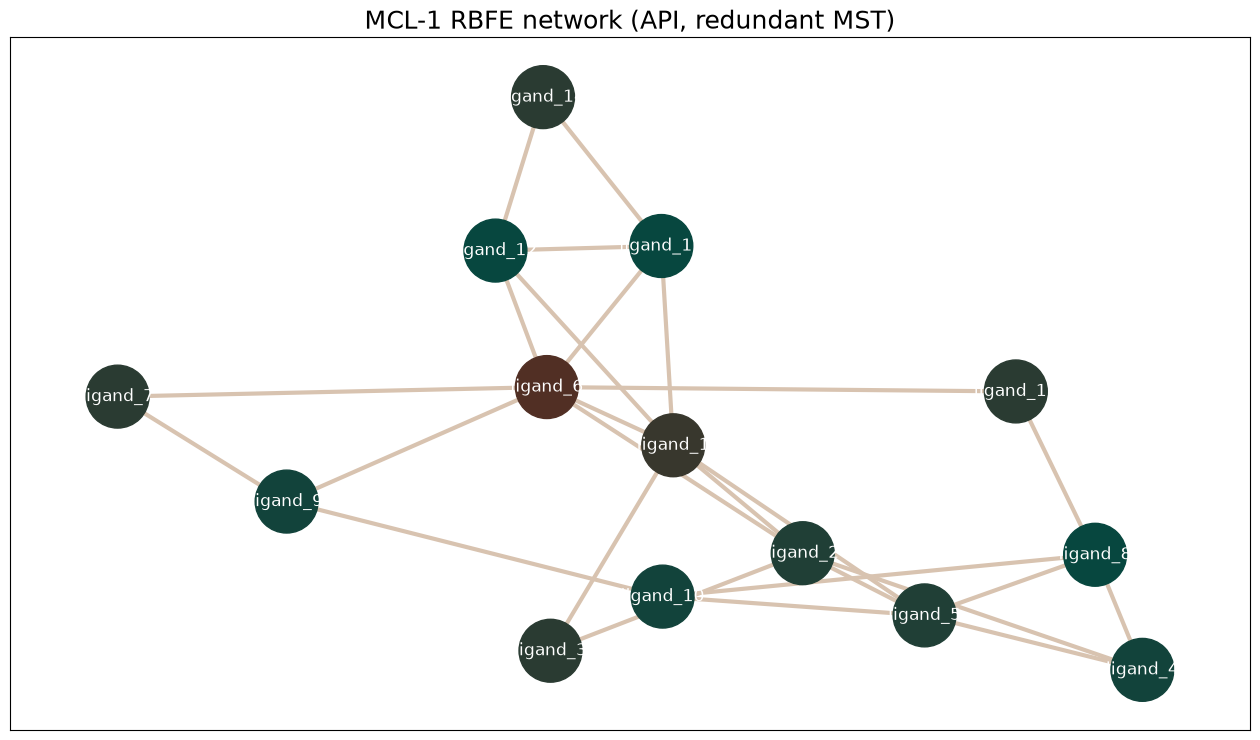

In [22]:
konnektor.draw_ligand_network(ligand_network, title="MCL-1 RBFE network (API, redundant MST)")

...and as an interactive widget, where you can drag nodes around and click an edge to inspect it:

In [23]:
from konnektor.visualization.widget import draw_network_widget

draw_network_widget(ligand_network)

interactive(children=(Dropdown(description='layout', index=4, options=('dagre', 'cola', 'breadthfirst', 'conce…

CytoscapeWidget(cytoscape_layout={'name': 'cose', 'nodeSpacing': 50, 'edgeLengthVal': 50}, cytoscape_style=[{'…

Each edge in the network gives you back the two ligands involved and the mapping between them —
remember, transformations always go from `componentA` to `componentB`:

In [24]:
an_edge = next(iter(ligand_network.edges))
an_edge.componentA.name, an_edge.componentB.name

('ligand_1', 'ligand_2')

<div style="background-color:#e8f5e9; border-left: 6px solid #4caf50; padding: 12px 16px; border-radius: 4px; margin: 10px 0;">

✏️ **Exercise**


Try building a couple of the other network topologies OpenFE offers, using the same `ligands`,
`mapper` and `scorer`:

- `openfe.ligand_network_planning.generate_minimal_spanning_network(...)` (a plain, non-redundant
  MST — this is what the CLI used above)
- `openfe.ligand_network_planning.generate_radial_network(ligands=..., mappers=..., scorer=...,
  central_ligand=ligands[0])` (a star network around one chosen ligand)

Visualise each one with `konnektor.draw_ligand_network`. You can save any `LigandNetwork` to disk
for later with `network.to_graphml()`, the same GraphML format the CLI produces.

Some questions to think about:

- Why might you want redundancy (extra edges) in a network, given it means more simulations to run?
- Why might you choose a radial network over a minimal spanning tree, or vice versa?


</div>

<div style="background-color:#d9edf7; border-left: 6px solid #2196F3; padding: 12px 16px; border-radius: 4px; margin: 10px 0;">

💡 **Info**


See the [Konnektor](https://github.com/OpenFreeEnergy/konnektor) and
[HiMap](https://github.com/OpenFreeEnergy/himap) repositories for more on the ideas behind
network topology and redundancy.


</div>

### Creating a protocol

<div style="background-color:#d9edf7; border-left: 6px solid #2196F3; padding: 12px 16px; border-radius: 4px; margin: 10px 0;">

💡 **Info**


A `Protocol` is OpenFE's description of *how* to compute a free energy difference between two
`ChemicalSystem`s — the sampling method, force field, simulation length, and everything else
needed to actually run and analyse the calculation. See the
[Choose and Configure a Protocol cookbook](https://docs.openfree.energy/en/stable/cookbook/choose_protocol.html)
for a general introduction.


</div>

The `RelativeHybridTopologyProtocol` is the OpenMM-based hybrid topology protocol we've been using
throughout this tutorial. As with everything else in OpenFE, the easiest way to customise its
settings is to start from the defaults and modify them:

In [25]:
from openff.units import unit
from openfe.protocols.openmm_rfe import RelativeHybridTopologyProtocol

settings = RelativeHybridTopologyProtocol.default_settings()

# 10 ns of production instead of the default 5 ns
settings.simulation_settings.production_length = 10.0 * unit.nanosecond

# a single repeat per transformation, as with the CLI's --n-protocol-repeats
settings.protocol_repeats = 1

# the newest force field, matched to the AshGC charges we generated above
settings.forcefield_settings.small_molecule_forcefield = "openff-2.3.0"

settings

{'alchemical_settings': {'endstate_dispersion_correction': False,
                         'explicit_charge_correction': False,
                         'explicit_charge_correction_cutoff': {'unit': 'nanometer',
                                                               'val': 0.8},
                         'softcore_LJ': 'gapsys',
                         'softcore_alpha': 0.85,
                         'turn_off_core_unique_exceptions': True,
                         'use_dispersion_correction': False},
 'engine_settings': {'compute_platform': 'cuda', 'gpu_device_index': None},
 'forcefield_settings': {'constraints': 'hbonds',
                         'forcefields': ['amber/ff14SB.xml',
                                         'amber/tip3p_standard.xml',
                                         'amber/tip3p_HFE_multivalent.xml',
                                         'amber/phosaa10.xml',
                                         'amber/lipid17_merged.xml'],
                    

Solvent and complex legs of the same transformation usually want slightly different settings — for
example, the complex leg doesn't need as much water padding around it, since most of the box is
already filled by the protein. Rather than set this by hand, we can reuse the same helper the CLI
uses internally, `RelativeHybridTopologyProtocol._adaptive_settings`, which adapts a settings
object based on the `ChemicalSystem`s and mapping it will be used for:

In [26]:
example_mapping = next(iter(ligand_network.edges))

example_stateA = openfe.ChemicalSystem({"ligand": example_mapping.componentA, "protein": protein, "solvent": solvent})
example_stateB = openfe.ChemicalSystem({"ligand": example_mapping.componentB, "protein": protein, "solvent": solvent})

complex_settings = RelativeHybridTopologyProtocol._adaptive_settings(
    stateA=example_stateA,
    stateB=example_stateB,
    mapping=example_mapping,
    initial_settings=settings,
)

print("solvent leg padding:", settings.solvation_settings.solvent_padding)
print("complex leg padding:", complex_settings.solvation_settings.solvent_padding)

solvent leg padding: 1.5 nanometer
complex leg padding: 1 nanometer


In [27]:
solvent_protocol = RelativeHybridTopologyProtocol(settings)
complex_protocol = RelativeHybridTopologyProtocol(complex_settings)

### Creating transformations

<div style="background-color:#d9edf7; border-left: 6px solid #2196F3; padding: 12px 16px; border-radius: 4px; margin: 10px 0;">

💡 **Info**


A `Transformation` is the object that actually ties everything together: two `ChemicalSystem`s
(the start and end states), the `LigandAtomMapping` between them, and the `Protocol` to use. It's
the object we eventually hand to `openfe quickrun`. See the
[Under the Hood cookbook](https://docs.openfree.energy/en/stable/cookbook/under_the_hood.html) for
more detail on `Transformation`s.


</div>

Just as with the CLI, every ligand pair (every edge in our network) needs **two**
`Transformation`s — one for the solvent leg, one for the complex leg. A `ChemicalSystem` is a
dictionary of `Component`s describing one end state: for the complex leg that's a ligand, the
protein, and the solvent; for the solvent leg it's just the ligand and the solvent.

Let's demonstrate this for a single mapping first, before doing it for the whole network:

In [28]:
mapping = next(iter(ligand_network.edges))

# the two ChemicalSystems for the solvent leg
solvent_stateA = openfe.ChemicalSystem({"ligand": mapping.componentA, "solvent": solvent})
solvent_stateB = openfe.ChemicalSystem({"ligand": mapping.componentB, "solvent": solvent})

# the two ChemicalSystems for the complex leg
complex_stateA = openfe.ChemicalSystem({"ligand": mapping.componentA, "protein": protein, "solvent": solvent})
complex_stateB = openfe.ChemicalSystem({"ligand": mapping.componentB, "protein": protein, "solvent": solvent})

solvent_transformation = openfe.Transformation(
    solvent_stateA,
    solvent_stateB,
    solvent_protocol,
    mapping=mapping,
    name=f"rbfe_{mapping.componentA.name}_solvent_{mapping.componentB.name}_solvent",
)
complex_transformation = openfe.Transformation(
    complex_stateA,
    complex_stateB,
    complex_protocol,
    mapping=mapping,
    name=f"rbfe_{mapping.componentA.name}_complex_{mapping.componentB.name}_complex",
)

solvent_transformation.name, complex_transformation.name

('rbfe_ligand_1_solvent_ligand_2_solvent',
 'rbfe_ligand_1_complex_ligand_2_complex')

Now let's do this for every edge in the network, building up the full `AlchemicalNetwork` — the
object describing the entire simulation campaign:

In [29]:
legs = {
    "solvent": {"solvent": solvent},
    "complex": {"solvent": solvent, "protein": protein},
}
protocols = {"solvent": solvent_protocol, "complex": complex_protocol}

transformations = []
for mapping in ligand_network.edges:
    for leg, shared_components in legs.items():
        stateA = openfe.ChemicalSystem({"ligand": mapping.componentA, **shared_components})
        stateB = openfe.ChemicalSystem({"ligand": mapping.componentB, **shared_components})
        name = f"rbfe_{mapping.componentA.name}_{leg}_{mapping.componentB.name}_{leg}"
        transformations.append(
            openfe.Transformation(stateA, stateB, protocols[leg], mapping=mapping, name=name)
        )

network = openfe.AlchemicalNetwork(transformations)
print(f"{len(network.edges)} transformations ({len(ligand_network.edges)} edges x 2 legs)")

52 transformations (26 edges x 2 legs)


### Writing Transformations to file

<div style="background-color:#d9edf7; border-left: 6px solid #2196F3; padding: 12px 16px; border-radius: 4px; margin: 10px 0;">

💡 **Info**


Nearly every OpenFE object — `LigandNetwork`, `Transformation`, `AlchemicalNetwork`, `Protocol`
settings, and more — can be written to a JSON file with `.to_json()` and read back with
`.from_json()`. See the
[Dumping a Transformation to JSON cookbook](https://docs.openfree.energy/en/stable/cookbook/dumping_transformation.html)
for details.


</div>

To actually run our campaign, we need to write each `Transformation` out to its own JSON file, so
that it can be picked up by `openfe quickrun`:

In [30]:
import pathlib

transformation_dir = pathlib.Path("transformations")
transformation_dir.mkdir(exist_ok=True)

for transformation in network.edges:
    transformation.to_json(transformation_dir / f"{transformation.name}.json")

!ls transformations | head

rbfe_ligand_12_complex_ligand_13_complex.json
rbfe_ligand_12_complex_ligand_14_complex.json
rbfe_ligand_12_solvent_ligand_13_solvent.json
rbfe_ligand_12_solvent_ligand_14_solvent.json
rbfe_ligand_13_complex_ligand_14_complex.json
rbfe_ligand_13_solvent_ligand_14_solvent.json
rbfe_ligand_1_complex_ligand_12_complex.json
rbfe_ligand_1_complex_ligand_13_complex.json
rbfe_ligand_1_complex_ligand_2_complex.json
rbfe_ligand_1_complex_ligand_3_complex.json


/home/bioc1523/software/mambaforge/install/envs/openfe/lib/python3.14/pty.py:66: DeprecationWarning: This process (pid=6213) is multi-threaded, use of forkpty() may lead to deadlocks in the child.
  pid, fd = os.forkpty()


### Executing our simulations

<div style="background-color:#fdecea; border-left: 6px solid #f44336; padding: 12px 16px; border-radius: 4px; margin: 10px 0;">

⚠️ **Warning**


As with the CLI section, we won't run any of these simulations here — 52 transformations
(26 edges × 2 legs) at 10 ns of production each is well beyond what we can do in a tutorial
session.

In practice, you'd execute each of these JSON files exactly the same way as in the CLI section,
using `openfe quickrun`:

```bash
openfe quickrun transformations/rbfe_ligand_1_complex_ligand_2_complex.json \
    -o results/openff-2.3.0-longer/rbfe_ligand_1_complex_ligand_2_complex.json \
    -d results/openff-2.3.0-longer/rbfe_ligand_1_complex_ligand_2_complex/
```


</div>

### Analysing results

<div style="background-color:#d9edf7; border-left: 6px solid #2196F3; padding: 12px 16px; border-radius: 4px; margin: 10px 0;">

💡 **Info**


This subsection (and the two below it) are placeholders: they describe what you would do once
you've actually run the campaign above under `results/openff-2.3.0-longer/`, but we haven't run
any simulations in this tutorial, so there's no results directory to show yet.

Once you have real results, analysis works exactly as it did with the CLI: point `openfe gather`
at your results directory (`openfe gather --report ddg results/openff-2.3.0-longer/`, etc.) to get
the same raw / ΔΔG / ΔG tables as before.


</div>

#### Looking at structural data

<div style="background-color:#d9edf7; border-left: 6px solid #2196F3; padding: 12px 16px; border-radius: 4px; margin: 10px 0;">

💡 **Info**


Each simulation's trajectory is stored as a NetCDF file (`simulation.nc`) inside its working
directory. Together with the input PDB, these can be loaded into an
[MDAnalysis](https://www.mdanalysis.org/) `Universe` — with some OpenFE-specific reader
conveniences provided by
[openfe-analysis](https://github.com/OpenFreeEnergy/openfe_analysis) — for further structural
analysis (RMSD, contacts, and so on). Again, we don't have any simulation output to load here, so
this is left as a pointer for once you have real trajectories to inspect.


</div>

#### Looking at networks of free energies using cinnabar

<div style="background-color:#d9edf7; border-left: 6px solid #2196F3; padding: 12px 16px; border-radius: 4px; margin: 10px 0;">

💡 **Info**


[Cinnabar](https://github.com/OpenFreeEnergy/cinnabar) is OpenFE's toolkit for analysing and
plotting networks of relative free energy results — for example, comparing our CLI and API results
side by side, or checking whether two ligands' predicted affinities are statistically
distinguishable (via maximum-likelihood cycle-closure analysis and CLD annotation). As with the
sections above, this needs completed simulation results that we don't have in this tutorial; see
the [cinnabar cookbook](https://docs.openfree.energy/en/stable/cookbook/cinnabar_absolute.html)
for a fully worked example once you have your own results to plot.


</div>

## Review & Conclusions

In this notebook we've planned two RBFE campaigns for the same MCL-1 fragment series:

- With the **OpenFE CLI**, in three commands (`charge-molecules`, `plan-rbfe-network`, and —
  in principle — `quickrun`/`gather`), using sensible best-practice defaults throughout.
- With the **OpenFE Python API**, customising the atom mapper, network topology, partial charge
  method, force field, and simulation length along the way, and building up the underlying
  `ChemicalSystem`, `Transformation`, and `AlchemicalNetwork` objects by hand.

Both routes end up in the same place: a directory of self-contained JSON files, one per simulation
leg, ready to be executed with `openfe quickrun` and combined with `openfe gather`.

<div style="background-color:#d9edf7; border-left: 6px solid #2196F3; padding: 12px 16px; border-radius: 4px; margin: 10px 0;">

💡 **Info**


If you've made it this far, you might want to try the advanced tutorials covering OpenFE's other
Protocols — for example running absolute binding free energies with **SepTop** or **ABFE**.
*(Note: these advanced tutorials haven't been written yet.)*


</div>